# Experiment: Whitened Koopman Singular Values Are Bounded by One

Objective:
- 回答问题：白化后的 Koopman 矩阵的最大奇异值是否一定不超过 1。
- 如果结论成立，给出严格数学证明。
- 用数值实验做 sanity check，避免只停留在符号推导。

Short answer:
- **成立**，前提是这里的“白化后的 Koopman 矩阵”指的是标准的
  $$
  \\bar K = C_{00}^{-1/2} C_{01} C_{11}^{-1/2},
  $$
  或在奇异协方差情形下对应的 Moore-Penrose / 支撑子空间版本。
- 这时不只是最大奇异值，**所有奇异值都不超过 1**。


In [1]:
from __future__ import annotations

from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np

SEED = 11
rng = np.random.default_rng(SEED)
np.set_printoptions(precision=4, suppress=True)
plt.style.use('seaborn-v0_8-whitegrid')

SEED


11

## Setup and Notation

记两个随机向量（或两个时间滞后特征向量）为
$$
X \in \mathbb{R}^m, \qquad Y \in \mathbb{R}^n.
$$
定义二阶矩矩阵
$$
C_{00} = \mathbb{E}[XX^\top], \qquad
C_{11} = \mathbb{E}[YY^\top], \qquad
C_{01} = \mathbb{E}[XY^\top].
$$
在协方差版本里，只需把 $X,Y$ 换成去均值后的变量即可，证明完全相同。

标准白化后的 Koopman / VAMP / TCCA 矩阵定义为
$$
\bar K = C_{00}^{-1/2} C_{01} C_{11}^{-1/2}.
$$
如果 $C_{00}, C_{11}$ 可逆，这是普通逆平方根；如果它们奇异，则在正特征值支撑上做白化，或等价地使用 Moore-Penrose 伪逆平方根。


## Theorem

**Theorem.** 设 $C_{00}$ 和 $C_{11}$ 是半正定矩阵，并按标准方式定义白化矩阵。那么白化后的 Koopman 矩阵 $\bar K$ 满足
$$
\sigma_{\max}(\bar K) \le 1.
$$
因此所有奇异值都满足
$$
\sigma_i(\bar K) \le 1.
$$

这说明白化后的奇异值本质上就是一组 canonical correlations，所以它们不可能超过 1。


## Proof 1: Cauchy-Schwarz Argument

先讨论 $C_{00}, C_{11}$ 可逆的情形。对任意单位向量 $u \in \mathbb{R}^m$、$v \in \mathbb{R}^n$，有
$$
\nu = u^\top \bar K v
= u^\top C_{00}^{-1/2} \, \mathbb{E}[XY^\top] \, C_{11}^{-1/2} v.
$$
把标量写进期望可得
$$
\nu = \mathbb{E}\big[(u^\top C_{00}^{-1/2} X)(v^\top C_{11}^{-1/2} Y)\big].
$$
定义两个标量随机变量
$$
\xi = u^\top C_{00}^{-1/2} X, \qquad
\eta = v^\top C_{11}^{-1/2} Y.
$$
于是
$$
\nu = \mathbb{E}[\xi \eta].
$$
由 Cauchy-Schwarz 不等式，
$$
|\nu| \le \sqrt{\mathbb{E}[\xi^2]}\sqrt{\mathbb{E}[\eta^2]}.
$$
下面分别计算这两个方差项：
$$
\mathbb{E}[\xi^2]
= u^\top C_{00}^{-1/2} \mathbb{E}[XX^\top] C_{00}^{-1/2} u
= u^\top C_{00}^{-1/2} C_{00} C_{00}^{-1/2} u
= u^\top u = 1.
$$
同理，
$$
\mathbb{E}[\eta^2] = 1.
$$
因此
$$
|u^\top \bar K v| \le 1
$$
对所有单位向量 $u,v$ 都成立。

而谱范数 / 最大奇异值的变分表征为
$$
\sigma_{\max}(\bar K) = \max_{\|u\|=\|v\|=1} |u^\top \bar K v|.
$$
故立刻得到
$$
\sigma_{\max}(\bar K) \le 1.
$$
又因为奇异值按降序排列，所以所有 $\sigma_i(\bar K) \le 1$。


## Proof 2: PSD Block Matrix Argument

这个证明更短，也更“矩阵化”。

块矩阵
$$
M = \mathbb{E}\left[
\begin{pmatrix} X \\ Y \end{pmatrix}
\begin{pmatrix} X \\ Y \end{pmatrix}^\top
\right]
=
\begin{pmatrix}
C_{00} & C_{01} \\
C_{10} & C_{11}
\end{pmatrix}
$$
显然是半正定的，因为它本身就是某个随机向量的二阶矩矩阵。

对它做合同变换
$$
D = \operatorname{diag}(C_{00}^{-1/2}, C_{11}^{-1/2}),
$$
得到
$$
D M D
=
\begin{pmatrix}
I & \bar K \\
\bar K^\top & I
\end{pmatrix}
\succeq 0.
$$
对这个块矩阵取 Schur complement，得到
$$
I - \bar K^\top \bar K \succeq 0.
$$
这等价于
$$
\bar K^\top \bar K \preceq I.
$$
因此其全部特征值都不超过 1，而这些特征值正是奇异值的平方：
$$
\lambda_i(\bar K^\top \bar K) = \sigma_i(\bar K)^2 \le 1.
$$
所以所有奇异值都不超过 1。


## Singular Covariances: What Changes?

如果 $C_{00}$ 或 $C_{11}$ 奇异，就在它们的正特征值支撑上白化。

设
$$
C_{00} = U_0 \Lambda_0 U_0^\top, \qquad
C_{11} = U_1 \Lambda_1 U_1^\top,
$$
其中只保留正特征值对应的列，记得到的 reduced whitening matrix 为
$$
\bar K_r = \Lambda_0^{-1/2} U_0^\top C_{01} U_1 \Lambda_1^{-1/2}.
$$
对 reduced coordinates 重复上面的 Cauchy-Schwarz 或 Schur complement 论证，仍然得到
$$
\sigma_i(\bar K_r) \le 1.
$$
而 full-space 的伪逆写法
$$
C_{00}^{+1/2} C_{01} C_{11}^{+1/2}
$$
与这个 reduced matrix 具有相同的非零奇异值，因此结论不变。

所以：
- **proper whitening**：奇异值一定不超过 1；
- **数值上偶尔大于 1**：通常来自有限精度、错误正则化、错误 whitening、或协方差估计不一致，而不是理论本身失效。


In [2]:
@dataclass
class SpectralCase:
    name: str
    sigma: np.ndarray
    B: np.ndarray


def invsqrt_psd(C: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    C = (C + C.T) / 2.0
    w, V = np.linalg.eigh(C)
    keep = w > eps
    if not np.any(keep):
        raise ValueError('All eigenvalues are below the cutoff; whitening is undefined.')
    return V[:, keep] @ np.diag(1.0 / np.sqrt(w[keep])) @ V[:, keep].T


def whitened_koopman(X: np.ndarray, Y: np.ndarray, center: bool = True, eps: float = 1e-12):
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)
    if center:
        X = X - X.mean(axis=0, keepdims=True)
        Y = Y - Y.mean(axis=0, keepdims=True)
    C00 = X.T @ X / len(X)
    C11 = Y.T @ Y / len(Y)
    C01 = X.T @ Y / len(X)
    B = invsqrt_psd(C00, eps=eps) @ C01 @ invsqrt_psd(C11, eps=eps)
    U, sigma, Vt = np.linalg.svd(B, full_matrices=False)
    return B, sigma, U, Vt.T


## Numerical Sanity Check 1: Random Gaussian Pairs

这里随机生成很多组相关高斯对 $(X, Y)$，每一组都计算标准白化后的 $\bar K$，检查是否出现 $\sigma_{\max} > 1$。


In [3]:
trial_sigmax = []
for _ in range(100):
    d = int(rng.integers(2, 7))
    n = 4000
    A = rng.normal(size=(d, d))
    noise = 0.35 * rng.normal(size=(n, d))
    X = rng.normal(size=(n, d))
    Y = X @ A.T + noise
    _, sigma, _, _ = whitened_koopman(X, Y, center=True)
    trial_sigmax.append(float(np.max(sigma)))

trial_sigmax = np.array(trial_sigmax)
summary = {
    'num_trials': int(len(trial_sigmax)),
    'max_sigma_max': float(trial_sigmax.max()),
    'min_sigma_max': float(trial_sigmax.min()),
    'all_leq_1_plus_1e-10': bool(np.all(trial_sigmax <= 1.0 + 1e-10)),
}
summary


{'num_trials': 100,
 'max_sigma_max': 0.9978900572944952,
 'min_sigma_max': 0.9361386833304474,
 'all_leq_1_plus_1e-10': True}

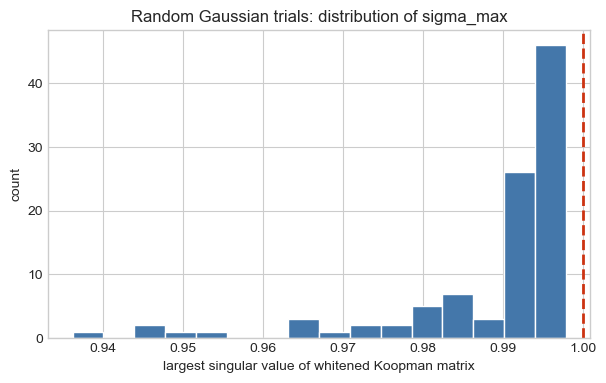

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(trial_sigmax, bins=16, color='#4477aa', edgecolor='white')
ax.axvline(1.0, color='#cc3311', linestyle='--', linewidth=2)
ax.set_title('Random Gaussian trials: distribution of sigma_max')
ax.set_xlabel('largest singular value of whitened Koopman matrix')
ax.set_ylabel('count')
plt.show()


## Numerical Sanity Check 2: Three Canonical Examples

这三组例子更接近前面讨论的动力学直觉：
- 保测圆周旋转：所有相关模态都应接近 1；
- 慢快 AR(1)：只有慢模态接近 1；
- metastable Markov chain：只有宏观块模态接近 1。


In [5]:
def build_rotation_case(rng: np.random.Generator, n: int = 120_000, omega: float = 0.37):
    theta = rng.uniform(0.0, 2 * np.pi, size=n)
    theta_next = (theta + omega) % (2 * np.pi)
    X = np.column_stack([
        np.cos(theta),
        np.sin(theta),
        np.cos(2 * theta),
        np.sin(2 * theta),
    ])
    Y = np.column_stack([
        np.cos(theta_next),
        np.sin(theta_next),
        np.cos(2 * theta_next),
        np.sin(2 * theta_next),
    ])
    B, sigma, _, _ = whitened_koopman(X, Y, center=True)
    return SpectralCase('Circle rotation', sigma, B)


def build_slow_fast_case(rng: np.random.Generator, T: int = 160_000):
    A = np.diag([0.995, 0.2])
    noise = np.diag([0.1, 0.1])
    x = np.zeros((T + 1, 2))
    for t in range(T):
        x[t + 1] = A @ x[t] + noise @ rng.normal(size=2)
    X = x[20_000:-1]
    Y = x[20_001:]
    B, sigma, _, _ = whitened_koopman(X, Y, center=True)
    return SpectralCase('Slow-fast AR(1)', sigma, B)


def build_metastable_case(rng: np.random.Generator, T: int = 220_000):
    P = np.array([
        [0.60, 0.39, 0.005, 0.005],
        [0.39, 0.60, 0.005, 0.005],
        [0.005, 0.005, 0.60, 0.39],
        [0.005, 0.005, 0.39, 0.60],
    ])
    s = np.empty(T + 1, dtype=int)
    s[0] = 0
    for t in range(T):
        s[t + 1] = rng.choice(4, p=P[s[t]])
    X = np.eye(4)[s[20_000:-1]]
    Y = np.eye(4)[s[20_001:]]
    B, sigma, _, _ = whitened_koopman(X, Y, center=True)
    return SpectralCase('Metastable chain', sigma, B)


cases = [
    build_rotation_case(rng),
    build_slow_fast_case(rng),
    build_metastable_case(rng),
]

for case in cases:
    print(case.name)
    print('sigma =', np.round(case.sigma, 6))
    print('sigma_max <= 1 ?', bool(case.sigma[0] <= 1.0 + 1e-10))
    print()


Circle rotation
sigma = [1. 1. 1. 1.]
sigma_max <= 1 ? True

Slow-fast AR(1)
sigma = [0.9947 0.2056]
sigma_max <= 1 ? True

Metastable chain
sigma = [0.9795 0.2135 0.2068 0.    ]
sigma_max <= 1 ? True



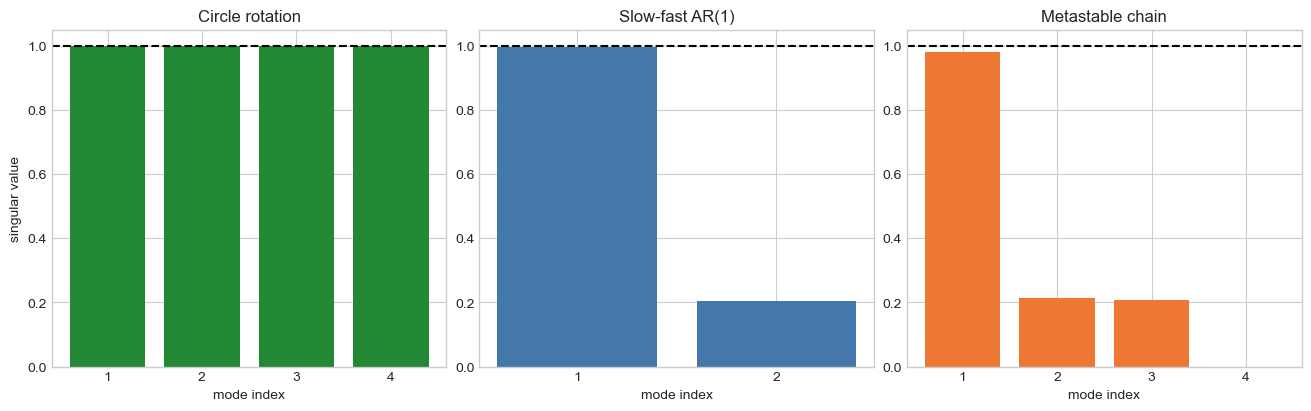

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
colors = ['#228833', '#4477aa', '#ee7733']
for ax, case, color in zip(axes, cases, colors):
    idx = np.arange(1, len(case.sigma) + 1)
    ax.bar(idx, case.sigma, color=color)
    ax.axhline(1.0, color='black', linestyle='--', linewidth=1.5)
    ax.set_ylim(0.0, 1.05)
    ax.set_xticks(idx)
    ax.set_title(case.name)
    ax.set_xlabel('mode index')
axes[0].set_ylabel('singular value')
plt.show()


## Conclusion

结论是肯定的：

- 对标准定义的白化 Koopman 矩阵
  $$
  \bar K = C_{00}^{-1/2} C_{01} C_{11}^{-1/2},
  $$
  最大奇异值一定不超过 1；事实上所有奇异值都不超过 1。
- 严格证明可以直接由 **Cauchy-Schwarz** 给出，也可以由块二阶矩矩阵的 **PSD + Schur complement** 给出。
- 如果你在实验里看到了奇异值大于 1，首先应怀疑：
  - whitening 不是按同一套 $C_{00}, C_{11}$ 做的；
  - 用了不一致的正则化；
  - 协方差矩阵数值上不稳定；
  - 或者实现上根本不是这个标准的 whitened Koopman / VAMP matrix。

所以，对你之前的问题，更精确的说法是：
- **是，proper whitening 下奇异值不会超过 1。**
- 因而“保留 near-1 modes”与“保留最大的奇异值”在排序逻辑上是一致的；真正需要仔细设计的是**截断规则**，不是这个上界本身。
